Correlation and Rule Evaluation for Phishing Discovery: A Comparative Study of Interestingness Measures

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import numpy as np
import time

data, meta = arff.loadarff('Training Dataset.arff')
df = pd.DataFrame(data)

for col in df.columns:
    df[col] = df[col].str.decode('utf-8').astype(int)

mapping={
    "having_IP_Address":  { -1: 'has_IP',1: 'no_IP' },
    "URL_Length":   { 1:'short_URL',0:'medium_URL',-1:'long_URL' },
    "Shortining_Service": { 1:'No_Shortining',-1:'Has_Shortining' },
    "having_At_Symbol":   { 1:'no_@_symbol',-1:'has_@_symbol' },
    "double_slash_redirecting": { -1:'last_position_bigger_than_7',1:'last_position_less_than_7' },
    "Prefix_Suffix":  { -1:'Has_PrefixSuffix',1:'No_PrefixSuffix' },
    "having_Sub_Domain":  { -1:'Multi_SubDomain',0:'One_SubDomain',1:'No_SubDomain' },
    "SSLfinal_State":  { -1:'No_HTTPS',1:'HTTPS_Trusted',0:'SSL_Suspicious' },
    "Domain_registeration_length":{ -1:'Domain_ShortTerm',1:'Domain_LongTerm' },
    "Favicon" :{ 1: 'Favicon_Internal',-1: 'Favicon_External' },
    "port" :{ 1:'Port_Standard',-1:'Port_NonStandard' },
    "HTTPS_token": { -1: 'Has_HTTPS_Token_In_Domain',1: 'No_HTTPS_Token_In_Domain' },
    "Request_URL":  { 1:'ReqURL_LowExtContent',-1:'ReqURL_HighExtContent' },
    "URL_of_Anchor": { -1:'greater_than_%67_Anchor',0:'between_%31_%67_Anchor',1:'less_than_%31_Anchor' },
    "Links_in_tags": { 1:'less_than_%17_Anchor',-1:'greater_than_%81_Anchor',0:'between_%17_%81_Anchor' },
    "SFH":  { -1:'Empty_or_Blank',1:'Same_Domain',0:'Diiferent_than_Domain' },
    "Submitting_to_email": { -1:'using_mail_func',1:'not_using_mail_func' },
    "Abnormal_URL": { -1:'no_hostname_in_URL',1:'hostname_in_URL' },
    "Redirect":  { 0: 'Redirect_between_2-4',1: 'Redirect_Less_Than_1' }, #bu kısımda sorun çıkacak glb 
    "on_mouseover":  { 1:'onMouseOver_doesnt_Changes_Status_Bar',-1:'onMouseOver_Changes_Status_Bar' },
    "RightClick" : { 1:'Enabled',-1:'Disabled' },
    "popUpWidnow" : { 1: 'No_Popup_Text_Fields',-1: 'Has_Popup_Text_Fields' },
    "Iframe" :{ 1: 'No_IFrame',-1: 'Has_IFrame' },
    "age_of_domain" : { -1: 'Domain_Age_Less_6Month',1: 'Domain_Age_More_6Month' },
    "DNSRecord"  : { -1: 'No_DNS_Record',1: 'Has_DNS_Record' },
    "web_traffic" : { -1: 'Low_Traffic',0: 'Medium_Traffic',1: 'High_Traffic' },
    "Page_Rank": { -1: 'PageRank_Low',1: 'PageRank_High' },
    "Google_Index":{ 1:'Indexed by Google',-1:'Not Indexed by Google' },
    "Links_pointing_to_page": { 1:'at least 2 external links pointing ',0:'have 1 or 2 links pointing',-1:'have no links pointing' },
    "Statistical_report": { -1:'Belongs to Top Phishing IPs/Domains',1:'Dont Belong to Top Phishing IPs/Domains' },
    "Result" : { -1: 'Phishing',1: 'Legitimate' },
}

df_mapped = df.copy()
for col, counts in mapping.items():
    df_mapped[col] = df_mapped[col].map(counts)

#print(df_mapped.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

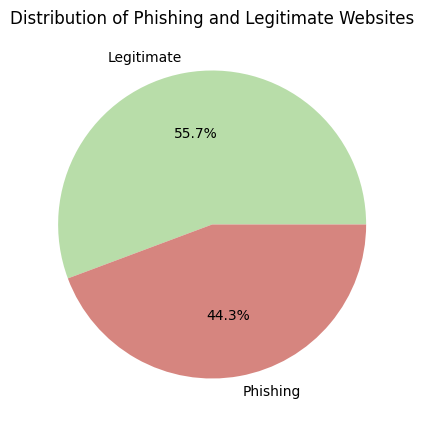

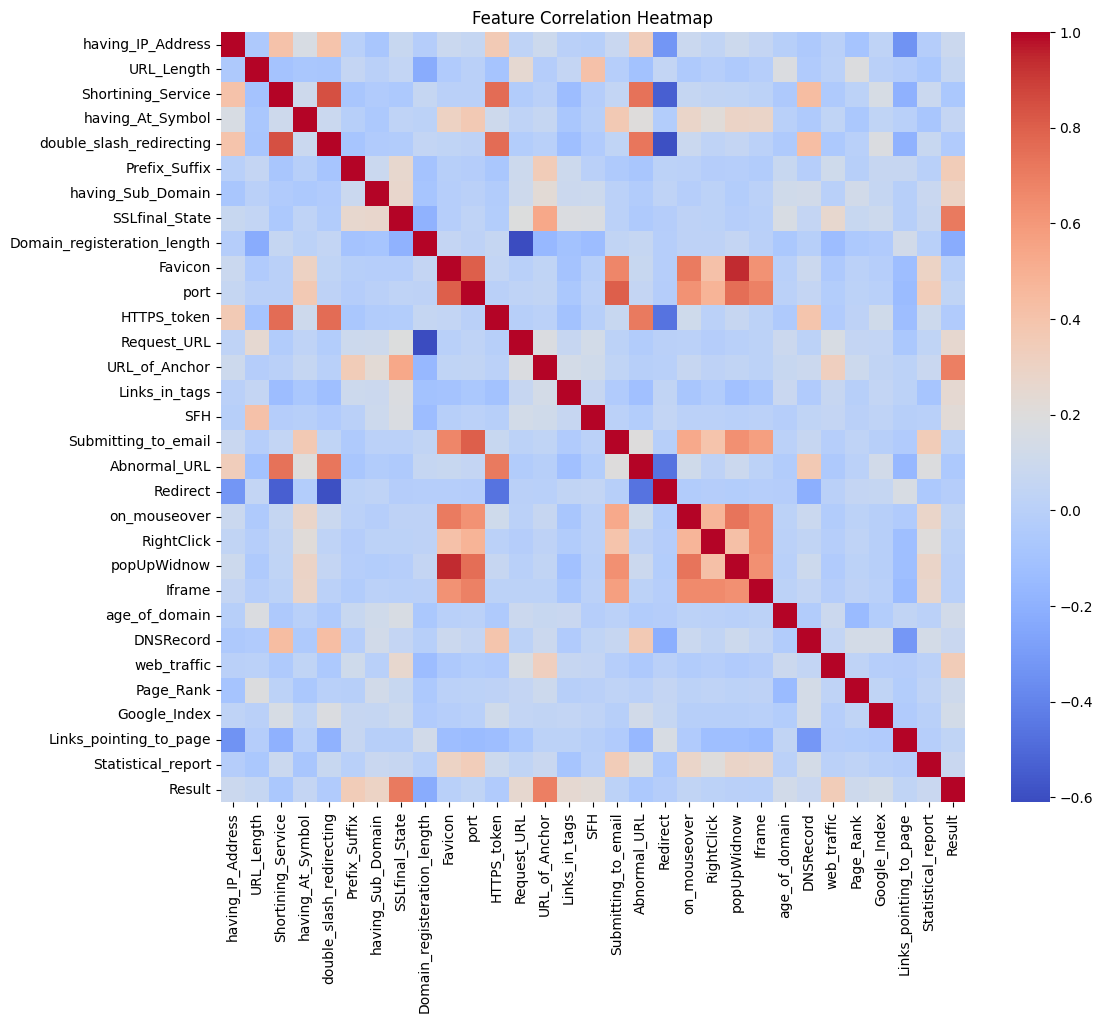

Critical Features:
 Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
Domain_registeration_length    0.225789
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
Name: Result, dtype: float64


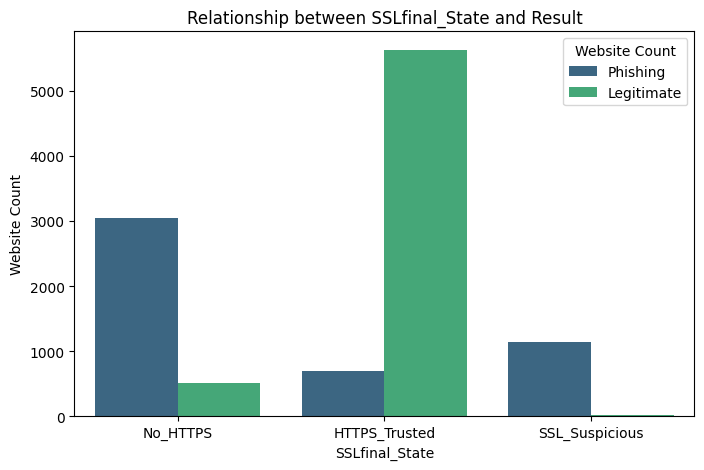

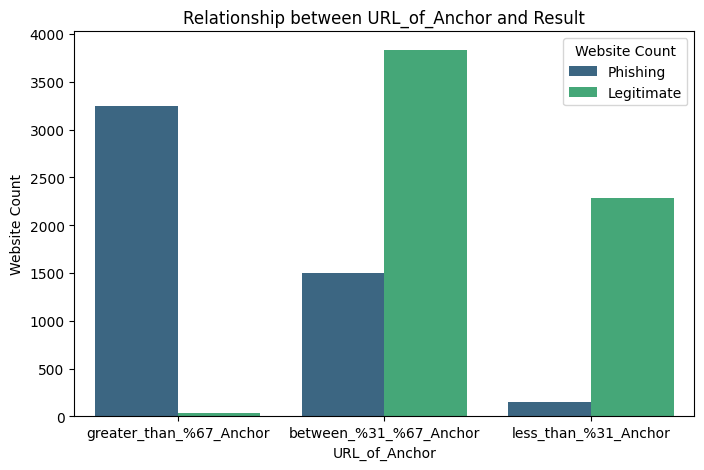

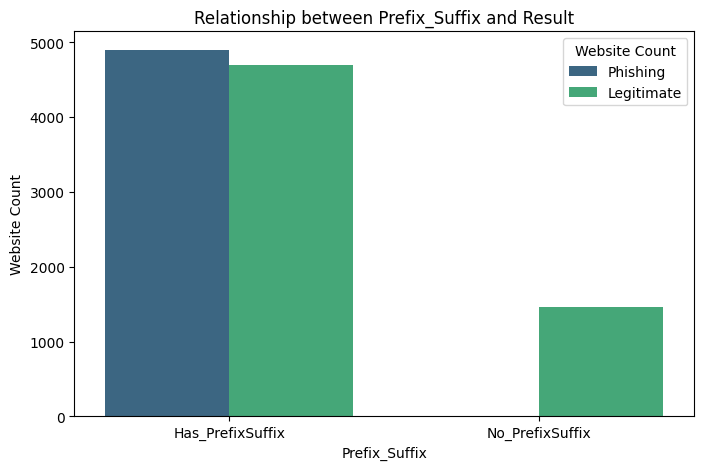

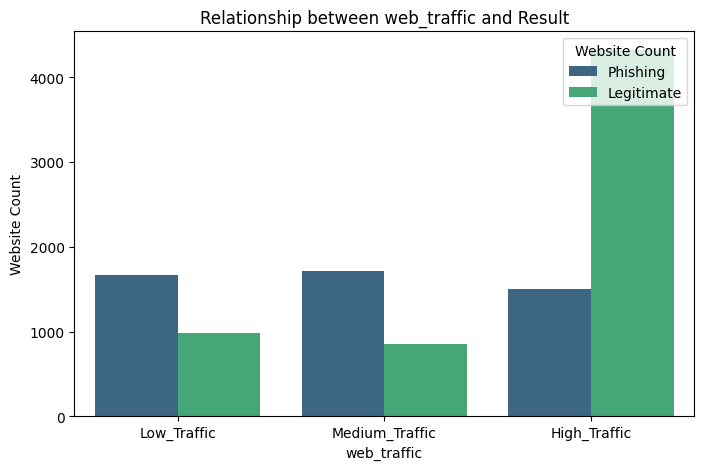

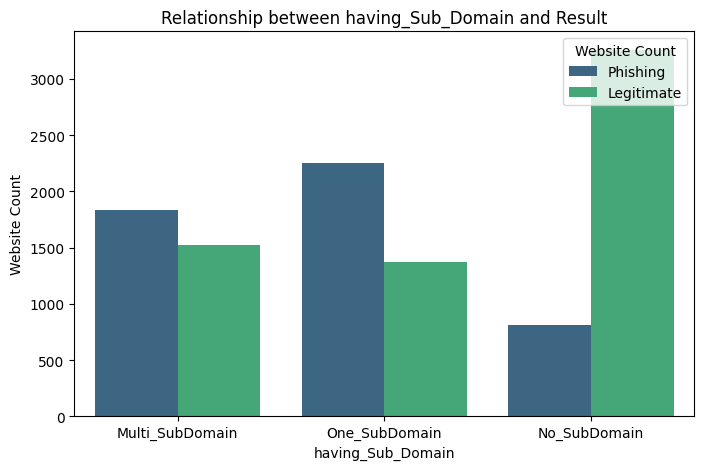

In [19]:
print(df_mapped.info())

for col in df_mapped.columns:
    print(f"--- {col} ---")
    print(df_mapped[col].value_counts())

plt.figure(figsize=(5,5))
pie_chart_colors=['#b8dda9',"#d6857f"]
df_mapped['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=pie_chart_colors)
plt.title('Distribution of Phishing and Legitimate Websites')
plt.ylabel('')
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

top_15_features = df.corr()['Result'].abs().sort_values(ascending=False).head(16)
feature_names = top_15_features.index[1:6]
print("Critical Features:\n", top_15_features)

for col_name in feature_names:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col_name, hue='Result', data=df_mapped, palette='viridis')
    plt.title(f'Relationship between {col_name} and Result')
    plt.xlabel(col_name)
    plt.ylabel('Website Count')
    plt.legend(title='Website Count', loc='upper right')
    plt.show()

The Apriori algorithm was applied using a minimum support of 0.15. Since using all features caused memory errors, only the top 15 features with the highest correlation to the 'Result' column were included in the mining process. Association rules were then generated with a minimum confidence of 0.60. These thresholds were chosen because higher values yielded very few or no results, preventing a comprehensive analysis of the dataset.

In [20]:
top_15_feature_names = top_15_features.index.tolist()
df_mining = df_mapped[top_15_feature_names]
df_rules = pd.get_dummies(df_mining)
#print(df_rules)

frequent_itemsets = apriori(df_rules, min_support=0.15, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.60)

phishing_rules = rules[
    (rules['consequents'] == frozenset({'Result_Phishing'})) 
#    | 
#    (rules['consequents'] == frozenset({'Result_Legitimate'}))
]
with open("phishing_specific_rules_with_minsup_0.15_minconf_0.6.txt", "w", encoding="utf-8") as f:
    f.write("RULES TARGETING PHISHING\n")
    f.write(phishing_rules.sort_values(by='lift', ascending=False).to_string())